In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Single objective

Max folder: 299


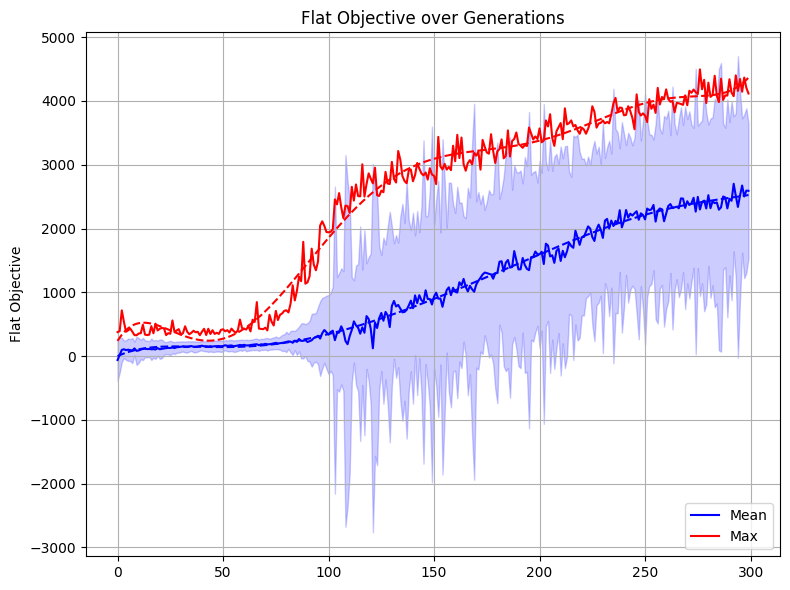

In [2]:
# plot mean and max of both objectives in f over generations. 
# For that read folders with f_best = np.load("results/20260401_113146_nsga_ckpts/i/f.npy") 
# for i in range(0, 600, 10) and plot the mean and max of f on y and generations on x on two subplots.
flat_mean = []
flat_max = []
flat_std = []


path = "results/2026-05-04_21-54-46_final_test"

max_folder = max([int(d) for d in os.listdir(path) if d.isdigit()])
print(f"Max folder: {max_folder}")

fig,axs = plt.subplots(1,1, figsize=(8, 6))
for i in range(0, max_folder+1):
    f = np.load(f"{path}/{i}/f.npy")
    flat_mean.append(np.mean(f, axis=0))
    flat_max.append(np.max(f, axis=0))
    
    flat_std.append(np.std(f, axis=0))

generations = np.arange(0, max_folder+1)

axs.plot(generations, flat_mean, label="Mean", color="blue")
axs.plot(generations, flat_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, flat_mean, 7)
p = np.poly1d(z)
axs.plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, flat_max, 7)
p = np.poly1d(z)
axs.plot(generations, p(generations), linestyle="--", color="red")    
axs.set_ylabel("Flat Objective")
axs.legend(loc="lower right")
axs.fill_between(generations, np.array(flat_mean) - np.array(flat_std), np.array(flat_mean) + np.array(flat_std), alpha=0.2, color="blue")
axs.grid("on")
axs.set_title("Flat Objective over Generations")



fig.tight_layout()


In [3]:
flat_mean[-1], flat_mean[0], flat_max[0], flat_max[-1]

(np.float64(2591.223215024615),
 np.float64(-62.419980430467454),
 np.float64(375.45321827799603),
 np.float64(4117.2042945174435))